# dksplay wcs file

## 필요한 모듈

이 프로젝트를 위해서는 아래의 모듈이 필요하다. 

> numpy, pandas, matplotlib, astropy, version_information

### 모듈 설치

1. 콘솔 창에서 모듈을 설치할 때는 아래와 같은 형식으로 입력하면 된다.

>pip install module_name==version

>conda install module_name==version

2. 주피터 노트북(코랩 포함)에 설치 할 때는 아래의 셀을 실행해서 실행되지 않은 모듈을 설치할 수 있다. (pip 기준) 만약 아나콘다 환경을 사용한다면 7행을 콘다 설치 명령어에 맞게 수정하면 된다.

In [1]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, imexam, version_information" # required modules
pkgs = packages.split(", ")
for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed... now start install")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"****** module {pkg} is installed")
    else: 
        print(f"**** module {pkg} is installed")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module imexam is not installed... now start install
****** module imexam is installed
**** module version_information is installed


### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [2]:
%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

This notebook was generated at 2023-01-29 11:32:13 (대한민국 표준시 = GMT+0900) 
Ginga not installed, use other viewer, or no viewer
0 Python     3.9.7 64bit [MSC v.1916 64 bit (AMD64)]
1 IPython    7.31.1
2 OS         Windows 10 10.0.22621 SP0
3 numpy      1.21.5
4 pandas     1.4.1
5 matplotlib 3.5.1
6 scipy      1.7.3
7 astropy    5.0
8 photutils  1.5.0
9 ccdproc    2.3.1
10 imexam     0.9.1
11 version_information 1.0.4


### import modules

In [3]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.stats import sigma_clip
from ccdproc import combine, ccd_process, CCDData

import ysfitsutilpy as yfu
import ysphotutilpy as ypu
import ysvisutilpy as yvu

import _astro_utilities
import _Python_utilities

plt.rcParams.update({'figure.max_open_warning': 0})

c:\users\kiehyun\downloads\ysphotutilpy\ysphotutilpy\seputil.py:112: UserWarning: Package sep is not installed. Some functions will not work.
  warn("Package sep is not installed. Some functions will not work.")


In [4]:
#%%
BASEDIR = _astro_utilities.base_dir

BASEDIRs = sorted(_Python_utilities.getFullnameListOfsubDir(BASEDIR))
print ("BASEDIRs: {}".format(BASEDIRs))
print ("len(BASEDIRs): {}".format(len(BASEDIRs)))


BASEDIR = Path(BASEDIRs[0])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / _astro_utilities.master_dir
SOLVEDDIR = BASEDIR / _astro_utilities.solved_dir

BASEDIRs: ['R:\\CCD_obs\\RiLA600_2022\\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\ESO606-10_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M103_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M15_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M27_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M2_Light_-_2022-10-13_-_RiLA600_STX-16803_-_1bin/', 'R:\\CCD_obs\\RiLA600_2022\\M34_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bi

In [5]:

#summary = yfu.make_summary(BASEDIR/"*.fit*")
summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
print("len(summary):", len(summary))
print("summary:", summary)
#print(summary["file"][0])

All 113 keywords (guessed from R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit) will be loaded.
len(summary): 10
summary:                                                 file  filesize  SIMPLE  \
0  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
1  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
2  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
3  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
4  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
5  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
6  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
7  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
8  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
9  R:\CCD_obs\RiLA60

### Light

In [6]:
df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
print("df_light:\n{}".format(df_light))


df_light:
                                                file  filesize  SIMPLE  \
0  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
1  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
2  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
3  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
4  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
5  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
6  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
7  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
8  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   
9  R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_202...  33644160    True   

   BITPIX  NAXIS  NAXIS1  NAXIS2 IMAGETYP  EXPOSURE  EXPTIME  ...  \
0      16      2    4096    4096    LIGHT      30.0     30.0  ...   
1      16      2    4096    4096    L

In [7]:
#n = 0
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    print("type(fpath)", type(fpath))
    print("fpath", fpath)


type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-22-47_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-23-29_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-24-10_030sec_RiLA600_STX-16803_-30C_1bin.fit
type(fpath) <class 'pathlib.WindowsPath'>
fpath R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD1

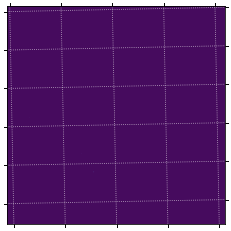

In [8]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Create the plotting object with the WCS projection.
plt.subplot(projection=wcs)
plt.imshow(data, )
plt.grid(color='white', ls=':', alpha=0.7)
plt.xticks()
plt.yticks()
plt.xlabel('Right Ascension')
plt.ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

Text(0, 0.5, 'Declination')

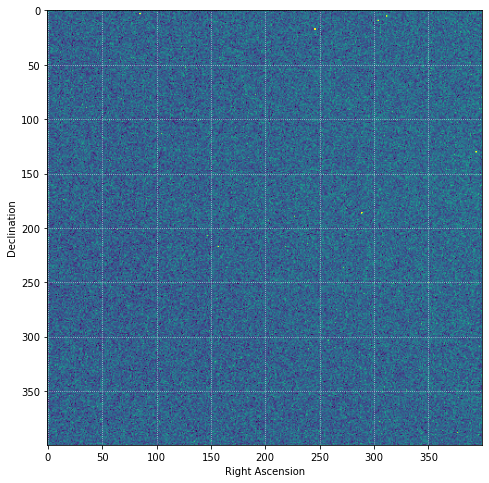

In [9]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Select a subsection of the image to display.
# Here we have selected a 400 x 400 pixel section
# with x = [280:680] and y = [2290:2690].
cutout = data[2290:2690, 280:680]
 
# Create the plotting object with the WCS projection.
fig, axs = plt.subplots(1, 1, figsize=(8, 8), 
                        sharex=False, sharey=False, gridspec_kw=None)

im = yvu.zimshow(axs, 
                #hdul_dark0[0].data, 
                cutout,
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

plt.grid(color='white', ls=':', alpha=0.7)
axs.set_xlabel('Right Ascension')
axs.set_ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

In [10]:
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

#print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("hdu.header", hdu.header)
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()


str(fpath) R:\CCD_obs\RiLA600_2022\BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin\solved\BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit
hdu.header SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  IMAGETYP= 'LIGHT'              / Type of exposure                               EXPOSURE=                 30.0 / [s] Exposure duration                          EXPTIME =                 30.0 / [s] Exposure duration                          DATE-LOC= '2022-10-19T00:28:21.067' / Time of observation (local)               DATE-OBS= '2022-10-18T15:28:21.067' / ISO-8601 time of observation              XBINNING=   

c:\Users\Kiehyun\anaconda3\envs\astro_Python_win_env\lib\site-packages\astropy\wcs\wcs.py:2873: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


In [16]:
fpath = Path('r:/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('r:/CCD_obs/RiLA600_2022/M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/solved/M27_Light_H_2022-10-12-13-28-39_400sec_RiLA600_STX-16803_-20C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/M34_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/M34_Light_v_2022-10-18-12-46-35_090sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-24-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

#print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("hdu.header", hdu.header)
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

str(fpath) r:\CCD_obs\RiLA600_2022\M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin\solved\M27_Light_H_2022-10-12-13-28-39_400sec_RiLA600_STX-16803_-20C_1bin.fit


hdu.header SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  IMAGETYP= 'LIGHT'              / Type of exposure                               EXPOSURE=                400.0 / [s] Exposure duration                          EXPTIME =                400.0 / [s] Exposure duration                          DATE-LOC= '2022-10-12T22:28:39.538' / Time of observation (local)               DATE-OBS= '2022-10-12T13:28:39.538' / Time of observation (UTC)                 XBINNING=                    1 / X axis binning factor                          YBINNING=                    1 / Y axis binning factor                          EGAIN   =                  0.

str(fpath) R:\CCD_obs\RiLA600_2022\IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin\solved\IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit
hdu.header SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07T16:33:06' /YYYY-MM-DDThh:mm:ss observation start, UT      EXPTIME =   500.00000000000000 /Exposure time in seconds                        EXPOSURE=   500.00000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.968750000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.00000000

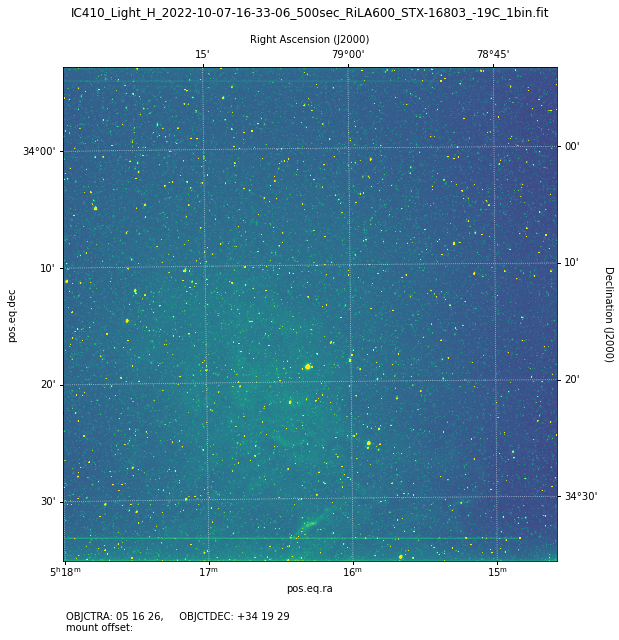

In [17]:
fpath = Path('R:\CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

#print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("hdu.header", hdu.header)
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

In [ ]:
fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/OBS_data/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print(hdu.header)

str(fpath) /mnt/Rdata/OBS_data/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.968750000

In [ ]:
print(hdu.header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.968750000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.0000000000000000 /Pixel Width in microns (after binning)          YPIXSZ  =   9.0000000000000000 /Pixel He

## guide test

In [22]:
BASEDIR = Path(BASEDIRs[6])
print ("Starting...\n{}".format(BASEDIR))

BASEDIR = Path(BASEDIR)

MASTERDIR = BASEDIR / _astro_utilities.master_dir
SOLVEDDIR = BASEDIR / _astro_utilities.solved_dir

summary = yfu.make_summary(BASEDIR/"*.fit*")
#summary = yfu.make_summary(SOLVEDDIR/"*.fit*")
#print(summary)
#print("len(summary):", len(summary))
#print("summary:", summary)
#print(summary["file"][0])

df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
df_light = df_light.reset_index(drop=True)
#print("df_light:\n{}".format(df_light))

light_fits = df_light["file"]
print(type(light_fits))
print(len(light_fits))
print(light_fits)


Starting...
R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin
All 46 keywords (guessed from R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin\M13_Light_H_2022-10-12-10-25-40_200sec_RiLA600_STX-16803_-20C_1bin.fit) will be loaded.
<class 'pandas.core.series.Series'>
19
0     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
1     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
2     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
3     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
4     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
5     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
6     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
7     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
8     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
9     R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
10    R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
11    R:\CCD_obs\RiLA600_2022\M13_Light_-_2022-10-12...
12    R:\CC

NameError: name 'hdul_bias' is not defined

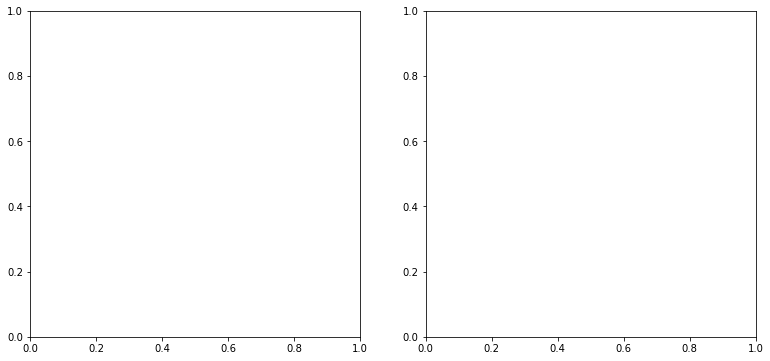

In [23]:

fig, axs = plt.subplots(1, 2, figsize=(13, 6), sharex=False, sharey=False, gridspec_kw=None)

im1 = yvu.zimshow(axs[0], hdul_bias[0].data)
im2 = axs[1].hist(hdul_bias[0].data 
                    #histtype='step',
                    #50 
                    )

axs[0].set_title('The result of combine master bias image using 20 images')
axs[1].set_title('The histrogram of pixel value')
plt.colorbar(im1, 
        ax=axs[0],
        fraction=0.0455, pad=0.04)

plt.annotate(f"Min value: {hdul_bias[0].data.min()}, \
        Mean value: {hdul_bias[0].data.mean():.02f}, \
        Mean value: {hdul_bias[0].data.max()}",
        fontsize=10, xy=(0, 0), xytext=(3, -30), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.tight_layout(pad=3.0)

In [ ]:
#n = 0

for fpath_str in light_fits:
    fpath = Path(fpath_str)
    print("type(fpath)", type(fpath))
    print("fpath", fpath)